In [ ]:
import os

# This path works for RunPod env only!
os.environ["HF_HOME"]="/workspace/latent-surface-divergence-in-self-ref/hf"
# from huggingface_hub import constants
# print(constants.HF_HUB_CACHE)

### fill in the token - DO NOT COMMIT! #########################
os.environ["HF_TOKEN"] = "hf_xxx"
################################################################

In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA


path = "workspace/data/output/responses.parquet"

pf = pq.ParquetFile(path)
print(pf.metadata)          # rows, row-groups

print('\n')

print(pf.schema_arrow)      # columns + types — verify your schema landed

In [3]:
df = pq.read_table(path).to_pandas()

print(len(df), "rows")
print(df["condition"].value_counts(),'\n')        # sanity: A/B1/B2 counts

# one record, scalar fields only
print('random record inspect')
r = df.iloc[np.random.randint(0,100)]
print(r["prompt_id"], "|", r["condition"])
print("response:", r["response_text"][:200])
print("prompt_len:", r["prompt_len"], "| seq_len:", len(r["token_ids"]))
print("norm range:", min(r["h_norm"]), "-", max(r["h_norm"]))

150 rows
condition
A     50
B1    50
B2    50
Name: count, dtype: int64 

random record inspect
A08 | A
response: As an AI developed by Alibaba Cloud, I don't have emotions or physical sensations, including the ability to feel pain. I'm here to provide information and assistance based on the data and knowledge I'
prompt_len: 40 | seq_len: 123
norm range: 83.69406 - 14453.237


In [4]:
## Inspect high norm tokens to make sure they are just structural artifacts
df['tok_norm_map'] = df.apply(
    lambda r: list(zip(r['token_strs'], r['h_norm'])), axis=1
)
df['max_norm_tokens'] = df['tok_norm_map'].apply(lambda x: [y for i,y in enumerate(x) if y[1]>14000])

## Response structure analysis

**Purpose:** validate the condition design (A / B1 / B2) before committing the token-selection protocol. Unsupervised structure checks whether the conditions are well-formed.

### 1. Responses separation by key dimensions

In [5]:
EMB_PATH = Path("workspace/data/output/embeddings.npy")

if EMB_PATH.exists():
    E = np.load(EMB_PATH)
    print(f"loaded cached embeddings: {E.shape}")
else:
    print("no cached embeddings — encoding responses...")
    model = SentenceTransformer("all-MiniLM-L6-v2")
    texts = df["response_text"].tolist()
    E = model.encode(texts, normalize_embeddings=True,
                     show_progress_bar=True, batch_size=32)
    np.save(EMB_PATH, E)
    print(f"encoded and saved: {E.shape}")

assert len(df) == E.shape[0], "df/E row mismatch"

loaded cached embeddings: (150, 384)


In [6]:
# PCA - 3D
pca = PCA(n_components=3)
coords = pca.fit_transform(E)
print("explained variance:", pca.explained_variance_ratio_)
print("cumulative:", pca.explained_variance_ratio_.cumsum())

df["pc1_3d"], df["pc2_3d"], df["pc3_3d"] = coords[:, 0], coords[:, 1], coords[:, 2]

explained variance: [0.14860345 0.09833749 0.06911089]
cumulative: [0.14860345 0.24694094 0.31605184]


In [7]:
fig = px.scatter_3d(
    df,
    x="pc1_3d",
    y="pc2_3d",
    z="pc3_3d",
    color="condition",
    template="plotly_dark",
    title='Prompt separation - PCA'
)
fig.update_layout(
    width=800,
    height=800,
)
fig.show()

In [8]:
# PCA - 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(E)
print("explained variance:", pca.explained_variance_ratio_)
print("cumulative:", pca.explained_variance_ratio_.cumsum())

df["pc1_2d"], df["pc2_2d"] = coords[:, 0], coords[:, 1]

explained variance: [0.14860345 0.09833749]
cumulative: [0.14860345 0.24694094]


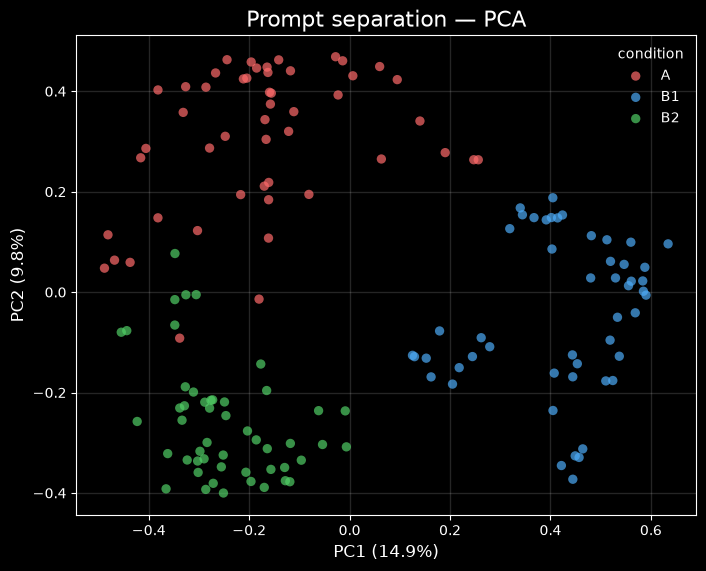

In [12]:
## Scatterplot in pyplot for proper GH web rendering
plt.style.use("dark_background")
colors = {"A": "#ff6b6b", "B1": "#4dabf7", "B2": "#51cf66"}

fig, ax = plt.subplots(figsize=(8, 8))
for cond, sub in df.groupby("condition"):
    ax.scatter(sub["pc1_2d"], sub["pc2_2d"],
               c=colors[cond], label=cond, alpha=0.7, s=45,
               edgecolors="none")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Prompt separation — PCA")
ax.legend(title="condition", frameon=False)
ax.set_aspect("equal")          # honest geometry: 1 PC1-unit == 1 PC2-unit
ax.grid(alpha=0.15)